# This project predicts the price of houses in Lagos 

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [27]:
#Load csv files into dataframe
df1 = pd.read_csv("rent.csv")
df2 = pd.read_csv("sale.csv")

print("df1 type:", type(df1))
print("df1 shape:", df1.shape)
print()
print("df2 type:", type(df2))
print("df2 shape:", df2.shape)
print()

df1 type: <class 'pandas.core.frame.DataFrame'>
df1 shape: (9853, 4)

df2 type: <class 'pandas.core.frame.DataFrame'>
df2 shape: (9784, 4)



In [3]:
df1.head()

,Price,Pid,Property_name,Address
0,"400,000 / year",H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos
1,"14,000,000 / year",G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos
2,"200,000 / year",H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos
3,"800,000 / year",H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos
4,"300,000 / year",H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos


In [21]:
df1["Price"] = df1["Price"].str.replace("/ year", "", regex=False).str.replace(",", "")
print("df1 type:", type(df1))
print("df1 shape:", df1.shape)
df1.head()

df1 type: <class 'pandas.core.frame.DataFrame'>
df1 shape: (9853, 6)


,Price,Pid,Property_name,Address,feature,location
0,400000,H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1 bedroom mini flat Flat / Apartment for rent,Fidiso Estate Abijo Ajah
1,14000000,G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3 bedroom Flat / Apartment for rent road,Gerrard Gerrard Gerard Road Ikoyi
2,200000,H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1 bedroom mini flat Flat / Apartment for rent,Obadia Akoka Yaba
3,800000,H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2 bedroom Flat / Apartment for rent,surulere Iju Ishaga Road Gbaja Surulere
4,300000,H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba


In [18]:

columns_to_iterate = ['Property_name', 'Address']

df1['feature'] = ''
df1['location'] = ''

for index, row in df1.iterrows():
    property_name = row['Property_name']
    address = row['Address']
    words = property_name.split()
    address_words = address.split()
    
    # Remove address words from property name
    for word in reversed(address_words):
        if word in words:
            words.remove(word)
    
    # Join remaining words to form feature
    feature = ' '.join(words)
    
    # Remove duplicates by splitting and joining
    feature_words = feature.split()
    feature_words = list(dict.fromkeys(feature_words))
    feature = ' '.join(feature_words)
    
    # Extract location from address
    location_words = address_words.copy()
    location_words = [word for word in location_words if word not in feature_words and word != 'Lagos']
    location = ' '.join(location_words)
    
    # Assign the feature and location to their respective columns
    df1.at[index, 'feature'] = feature
    df1.at[index, 'location'] = location
# Print the modified DataFrame
df1.head()


,Price,Pid,Property_name,Address,feature,location
0,400000,H1190,1 bedroom mini flat Flat / Apartment for rent ...,Fidiso Estate Abijo Ajah Lagos,1 bedroom mini flat Flat / Apartment for rent,Fidiso Estate Abijo Ajah
1,14000000,G7398,3 bedroom Flat / Apartment for rent Gerrard Ge...,Gerrard Gerrard Gerard Road Ikoyi Lagos,3 bedroom Flat / Apartment for rent road,Gerrard Gerrard Gerard Road Ikoyi
2,200000,H5843,1 bedroom mini flat Flat / Apartment for rent ...,Obadia Akoka Yaba Lagos,1 bedroom mini flat Flat / Apartment for rent,Obadia Akoka Yaba
3,800000,H1194,2 bedroom Flat / Apartment for rent Iju Ishaga...,surulere Iju Ishaga Road Gbaja Surulere Lagos,2 bedroom Flat / Apartment for rent,surulere Iju Ishaga Road Gbaja Surulere
4,300000,H5842,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba Lagos,1 bedroom mini flat Flat / Apartment for rent ...,Close to Unilag Abule Oja Yaba


In [20]:
# check for missing values:
df1.isnull().sum()

Price            0
Pid              0
Property_name    0
Address          0
feature          0
location         0
dtype: int64

In [23]:
#Save to csv
df1.to_csv("./LagosHousesCleaned.csv", index=False)

# EXPLORATORY DATA ANALYSIS

### Histogram

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



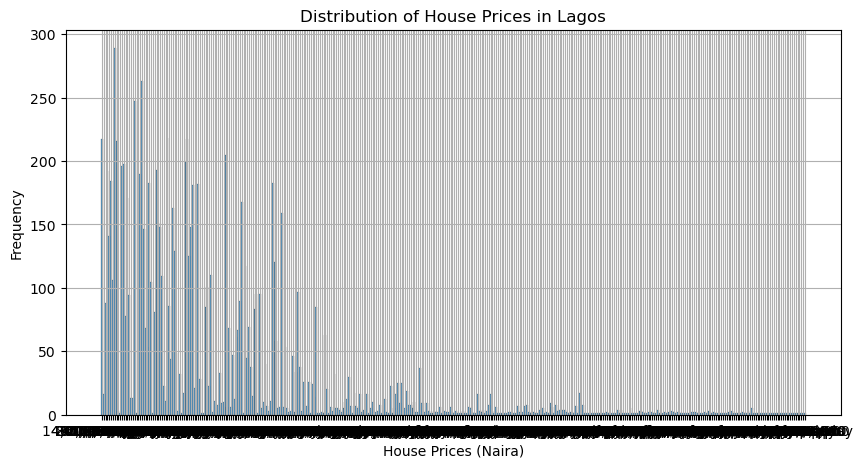

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(df1["Price"], bins=10, kde=True)  # kde=True adds a smooth density curve
plt.xlabel("House Prices (Naira)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices in Lagos")
plt.grid(True)
plt.show()



### Box Plot

In [ ]:
df1["Price"] = df1["Price"].str.replace(",", "").astype(int)


In [45]:
df1["Price"] = df1["Price"].str.extract(r"(\d+)").astype(int)


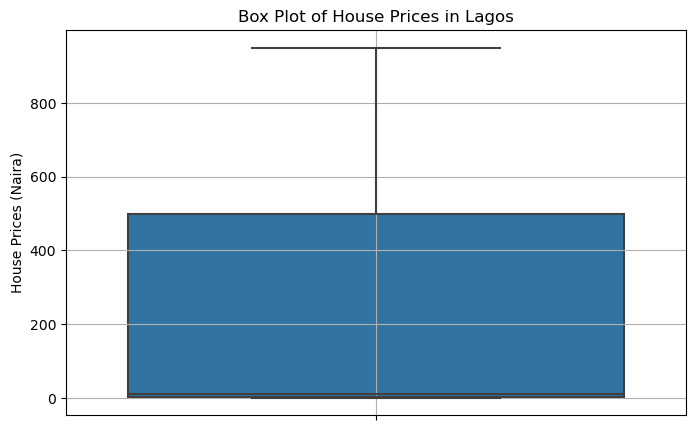

In [46]:
# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=df1["Price"])
plt.ylabel("House Prices (Naira)")
plt.title("Box Plot of House Prices in Lagos")
plt.grid(True)
plt.show()